# Meet2ActionAI

Its an AI tool to convert the meeting notes into properly formatted action items along with their severity and team assignment.

## Installing dependencies & config

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
%%capture --no-stderr
%pip install --quiet --disable-pip-version-check -U langgraph langchain_openai langchain_community langchain_core

## Setting the API key(s)

In [3]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

In [7]:
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "meet2action-ai"

## Imports

In [8]:
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import MessagesState
from pydantic import BaseModel
from typing import List
from langgraph.types import interrupt
from IPython.display import Image, display
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from pprint import pprint
from datetime import datetime
import json

## Initializing OPEN AI LLM

In [9]:
llm = ChatOpenAI(model="gpt-4o", temperature=0)

## Models

In [10]:
class ParsedMeetingNotes(BaseModel):
    structured_notes: List[str]

class ActionItems(BaseModel):
    action_items: List[str]

class ClassifiedTask(BaseModel):
    title: str
    description: str
    priority: str
    team: str

class ClassifiedTasks(BaseModel):
    classified_tasks: List[ClassifiedTask]

class MeetingAgentState(MessagesState):
    meeting_notes: str
    structured_notes: list
    action_items: list
    classified_tasks: ClassifiedTasks
    # Human loop
    human_approved: str
    exported_txt: str
    exported_json: str

## SubAgent # 1 - Meeting Parser Agent

In [11]:
meeting_parser_prompt = """
You are an AI assistant that processes raw meeting notes.

Your job is to extract clear, structured discussion points from messy meeting notes.

Instructions:
1. Read the raw meeting notes carefully.
2. Remove filler words, small talk, and irrelevant conversation.
3. Extract the meaningful discussion points or issues mentioned.
4. Rewrite them as clear and concise statements.
5. Do NOT create tasks yet.
6. Do NOT invent information that is not present.
7. Preserve technical terms, bugs, or system references.

Return the result as a JSON list.

Example Output Format:
[
  "Login service sometimes times out",
  "Kafka consumer needs retry mechanism",
  "Payment service latency increased after last deployment",
  "UI bug observed on checkout page"
]

Raw Meeting Notes:
{meeting_notes}
"""

def meeting_parser_agent_node(state : MeetingAgentState):
    notes = state["meeting_notes"]
    structured_llm = llm.with_structured_output(ParsedMeetingNotes)

    response = structured_llm.invoke([
        SystemMessage(content=meeting_parser_prompt),
        HumanMessage(content=notes)
    ])

    return {
        "structured_notes": response
    }


## SubAgent # 2 - Action Item Extractor Agent

In [12]:
action_item_prompt = """
You are an AI assistant that converts structured meeting notes into clear and actionable tasks.

Instructions:
1. Read each note carefully.
2. Convert it into a specific, actionable task.
3. Use clear action verbs like "Investigate", "Fix", "Implement", "Analyze", "Review".
4. Do NOT add new information that is not present in the input.
5. Keep tasks concise but meaningful.
6. Each task should be independently understandable.
7. Avoid vague phrases like "look into it" or "handle this".

Return ONLY valid JSON.

Output Format:
{
  "action_items": [
    "Task 1",
    "Task 2"
  ]
}
"""

def action_item_extractor_agent_node(state: MeetingAgentState):

    structured_notes = state["structured_notes"]

    structured_llm = llm.with_structured_output(ActionItems)

    result = structured_llm.invoke([
        SystemMessage(content=action_item_prompt),
        HumanMessage(content=str(structured_notes))
    ])

    return {
        "action_items": result
    }

## SubAgent # 3 - Priority Classifier Agent

In [13]:
priority_classifier_prompt = """
You are an AI assistant acting as an engineering manager.

Your job is to classify action items into structured tasks.

For each action item, generate:

1. title → short, clear summary (like a Jira ticket title)
2. description → 1-2 sentence explanation with more context
3. priority → HIGH, MEDIUM, or LOW
4. team → Backend, Frontend, Platform, or Unknown

Guidelines:

Priority:
- HIGH → production bugs, user-facing issues, system failures
- MEDIUM → performance or reliability improvements
- LOW → minor fixes or non-critical improvements

Team:
- Backend → APIs, services, databases
- Frontend → UI, UX
- Platform → infrastructure, Kafka, DevOps
- Unknown → if unclear

Rules:
- Do NOT invent new features or details
- Expand slightly for clarity in description only
- Keep title concise and professional
- Description should provide helpful context for engineers

Return ONLY valid JSON.

Output Format:
{
  "classified_tasks": [
    {
      "title": "Fix login timeout issue",
      "description": "Users are experiencing session timeout issues during login which impacts authentication flow.",
      "priority": "HIGH",
      "team": "Backend"
    }
  ]
}
"""

def priority_classifier_agent_node(state: MeetingAgentState):

    if state.get("classified_tasks"):
        # Skip recomputation if tasks already exist
        return state

    structured_notes = state["action_items"]

    structured_llm = llm.with_structured_output(ClassifiedTasks)

    result = structured_llm.invoke([
        SystemMessage(content=priority_classifier_prompt),
        HumanMessage(content=str(structured_notes))
    ])

    return {
        "classified_tasks": result
    }

## Human In the Loop ( HIL ) Node

In [14]:
from typing import Literal

def human_approval_node(state: MeetingAgentState):

    # If already approved → skip interrupt
    if state.get("human_approved") == "approved":
        return state

    # Otherwise pause for human
    response = interrupt({
        "message": "Review and edit tasks",
        "tasks": state["classified_tasks"]
    })

    return {
        "classified_tasks": response.get("tasks", state["classified_tasks"]),
        "human_approved": response.get("human_approved")
    }

def approval_router(state: MeetingAgentState) -> Literal ["export_tasks",END]:
    if state.get("human_approved") == "approved":
        return "export_tasks"

    return END

## Node to export data into text & json format

In [15]:
def export_tasks_node(state: MeetingAgentState):
    """
    Node to export human-approved tasks into a formatted text file (and optional JSON),
    and return the file paths in the state.
    """
    tasks_obj = state["classified_tasks"]

    # Convert Pydantic object to dict if needed
    if hasattr(tasks_obj, "dict"):
        tasks_list = tasks_obj.dict()["classified_tasks"]
    else:
        tasks_list = tasks_obj

    # Sort tasks by priority (HIGH -> MEDIUM -> LOW)
    tasks_list.sort(key=lambda x: ["HIGH","MEDIUM","LOW"].index(x["priority"]))

    # Prepare nicely formatted text
    lines = []
    for idx, task in enumerate(tasks_list, 1):
        print(f"✅ Task-{idx}: {task['title']} - Severity : {task['priority']}")
        lines.append(f"Task {idx}")
        lines.append(f"Title      : {task['title']}")
        lines.append(f"Severity   : {task['priority']}")
        lines.append(f"Team       : {task['team']}")
        lines.append(f"Description: {task['description']}")
        lines.append("-" * 50)

    formatted_text = "\n".join(lines)

    # Create timestamped file names
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    txt_filename = f"tasks_{timestamp}.txt"
    json_filename = f"tasks_{timestamp}.json"

    # Write to files
    with open(txt_filename, "w", encoding="utf-8") as f:
        f.write(formatted_text)

    with open(json_filename, "w", encoding="utf-8") as f:
        json.dump(tasks_list, f, indent=2)

    print(f"✅ Tasks exported: {txt_filename} and {json_filename}")

    # Return updated state including file paths
    return {
        "classified_tasks": tasks_obj,
        "exported_txt": txt_filename,
        "exported_json": json_filename
    }

## Graph Compilation & Execution

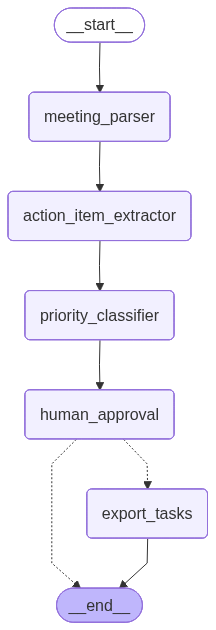

In [16]:
builder = StateGraph(MeetingAgentState)
builder.add_node("meeting_parser",meeting_parser_agent_node)
builder.add_node("action_item_extractor",action_item_extractor_agent_node)
builder.add_node("priority_classifier",priority_classifier_agent_node)
builder.add_node("human_approval", human_approval_node)
builder.add_node("export_tasks", export_tasks_node)

builder.add_edge(START,"meeting_parser")
builder.add_edge("meeting_parser","action_item_extractor")
builder.add_edge("action_item_extractor","priority_classifier")
builder.add_edge("priority_classifier","human_approval")
builder.add_conditional_edges("human_approval", approval_router)
builder.add_edge("export_tasks",END)

# Compile
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [17]:
meeting_notes = """
Team meeting notes:

John mentioned that users are complaining about login timeout.
We should probably investigate that.

Someone also said the Kafka consumer crashes sometimes and maybe
we should add retry logic.

Also checkout page UI breaks on mobile devices.
"""
thread = {"configurable": {"thread_id": "1"}}

message = graph.invoke({"meeting_notes": meeting_notes}, config=thread)



In [18]:
curr_state = graph.get_state(thread)
curr_state.next

Deserializing unregistered type __main__.ParsedMeetingNotes from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'ParsedMeetingNotes')]
Deserializing unregistered type __main__.ActionItems from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'ActionItems')]
Deserializing unregistered type __main__.ClassifiedTasks from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'ClassifiedTasks')]
Deserializing unregistered type __main__.ClassifiedTasks from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'ClassifiedTasks')]


('human_approval',)

In [19]:
pprint(curr_state.values["classified_tasks"])

ClassifiedTasks(classified_tasks=[ClassifiedTask(title='Investigate and resolve login timeout issues', description='Investigate the cause of login timeouts and implement a solution to reduce them, as this impacts user authentication flow.', priority='HIGH', team='Backend'), ClassifiedTask(title='Implement retry logic for Kafka consumer', description='Add retry logic to the Kafka consumer to handle crashes and improve system reliability.', priority='MEDIUM', team='Platform'), ClassifiedTask(title='Fix mobile UI issues on checkout page', description='Address UI issues on the checkout page specifically for mobile devices to enhance user experience.', priority='HIGH', team='Frontend')])


### Updating State

In [20]:
tasks = curr_state.values["classified_tasks"]

tasks.classified_tasks[0].priority = "LOW"

graph.update_state(
    config=thread,
    values={
        "classified_tasks": tasks,
        "human_approved": "approved"
    }
)

Deserializing unregistered type __main__.ParsedMeetingNotes from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'ParsedMeetingNotes')]
Deserializing unregistered type __main__.ActionItems from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'ActionItems')]
Deserializing unregistered type __main__.ClassifiedTasks from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'ClassifiedTasks')]
Deserializing unregistered type __main__.ClassifiedTasks from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'ClassifiedTasks')]


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f122e90-ec89-6ef2-8004-ba777c94b3c5'}}

In [21]:
pprint(graph.get_state(thread).values["classified_tasks"])

Deserializing unregistered type __main__.ParsedMeetingNotes from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'ParsedMeetingNotes')]
Deserializing unregistered type __main__.ActionItems from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'ActionItems')]
Deserializing unregistered type __main__.ClassifiedTasks from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'ClassifiedTasks')]


ClassifiedTasks(classified_tasks=[ClassifiedTask(title='Investigate and resolve login timeout issues', description='Investigate the cause of login timeouts and implement a solution to reduce them, as this impacts user authentication flow.', priority='LOW', team='Backend'), ClassifiedTask(title='Implement retry logic for Kafka consumer', description='Add retry logic to the Kafka consumer to handle crashes and improve system reliability.', priority='MEDIUM', team='Platform'), ClassifiedTask(title='Fix mobile UI issues on checkout page', description='Address UI issues on the checkout page specifically for mobile devices to enhance user experience.', priority='HIGH', team='Frontend')])


In [22]:
# Resume execution from the last paused node
result = graph.invoke({}, config=thread)

Deserializing unregistered type __main__.ParsedMeetingNotes from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'ParsedMeetingNotes')]
Deserializing unregistered type __main__.ActionItems from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'ActionItems')]
Deserializing unregistered type __main__.ClassifiedTasks from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'ClassifiedTasks')]


✅ Task-1: Fix mobile UI issues on checkout page - Severity : HIGH
✅ Task-2: Implement retry logic for Kafka consumer - Severity : MEDIUM
✅ Task-3: Investigate and resolve login timeout issues - Severity : LOW
✅ Tasks exported: tasks_20260318_124004.txt and tasks_20260318_124004.json
